In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Încărcarea setului de date
#housing = pd.read_csv('AmesHousing.csv')
housing = pd.read_csv('AmesHousing.csv', sep='\t')

# Afișarea primelor 5 rânduri
housing.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [2]:
#separation numeric - categorical features
numeric_features = housing.select_dtypes(include=['int64', 'float64']).columns
categorical_features = housing.select_dtypes(include=['object']).columns

print("Dataset contsins {} numeric features and {} categorical features.".format(len(numeric_features), len(categorical_features)))

#identification -> missing data
missing_data = housing.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("Colums with missing data (NaN) and their counts:")
print(missing_data)

Dataset contsins 39 numeric features and 43 categorical features.
Colums with missing data (NaN) and their counts:
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64


C:\Users\andre\AppData\Local\Temp\ipykernel_41516\2942377493.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = housing.select_dtypes(include=['object']).columns


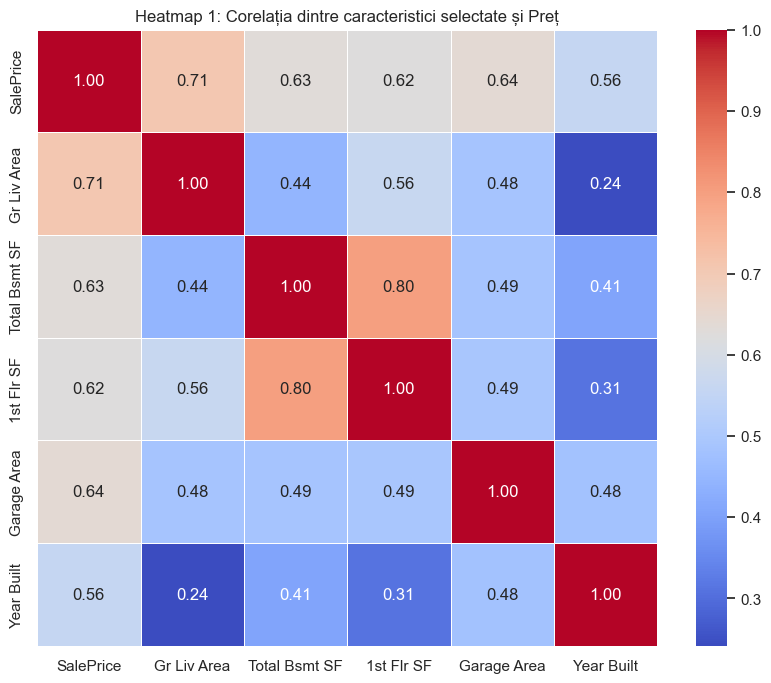

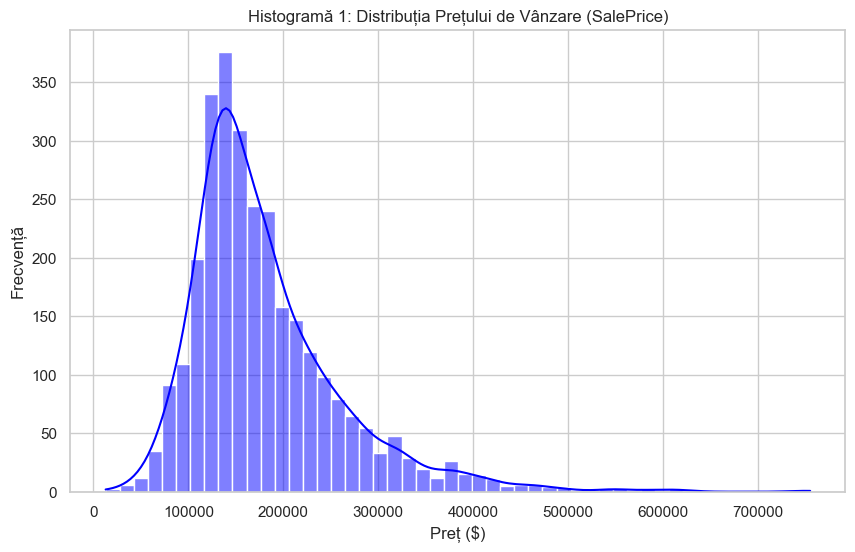

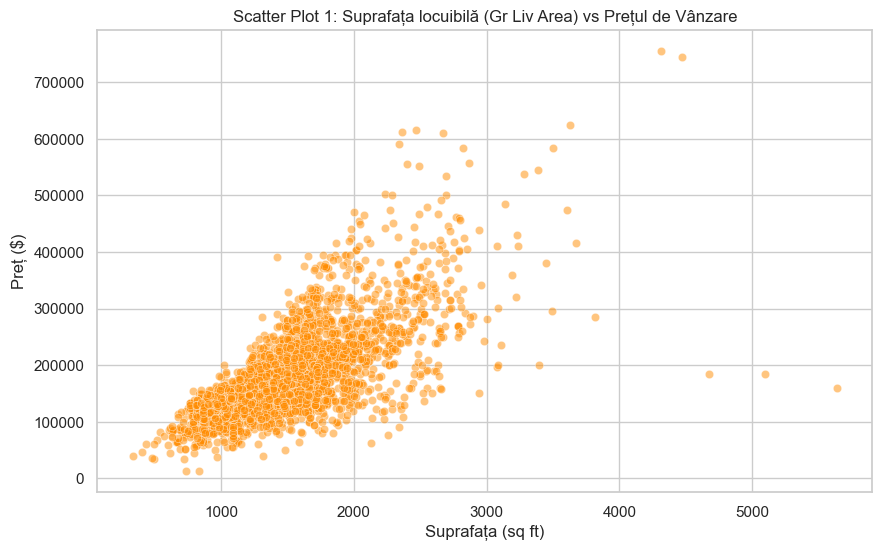

C:\Users\andre\AppData\Local\Temp\ipykernel_41516\3305430050.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Overall Qual', y='SalePrice', data=housing, palette='viridis')


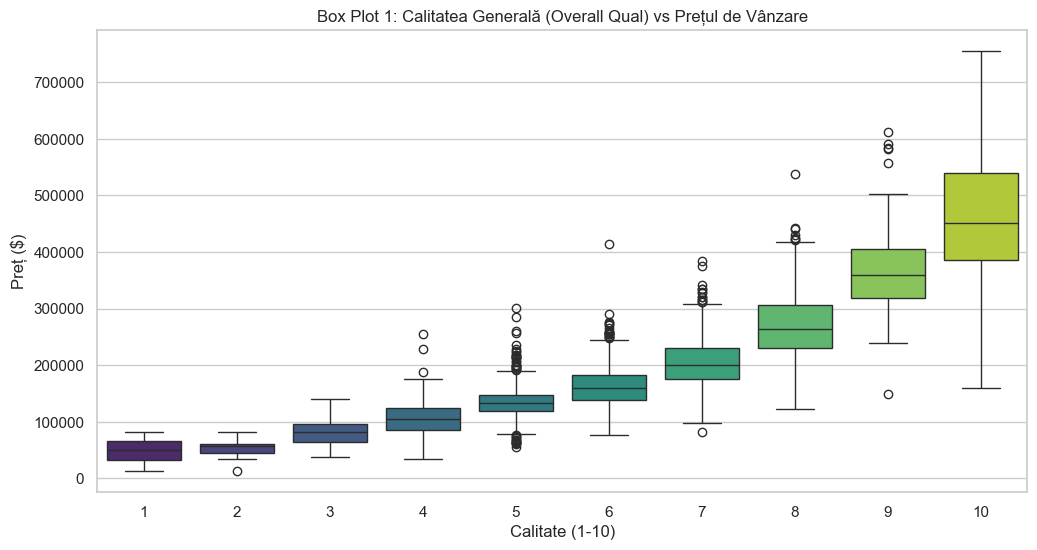

C:\Users\andre\AppData\Local\Temp\ipykernel_41516\3305430050.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Kitchen Qual', y='SalePrice', data=housing, order=['Po', 'Fa', 'TA', 'Gd', 'Ex'], palette='Set2')


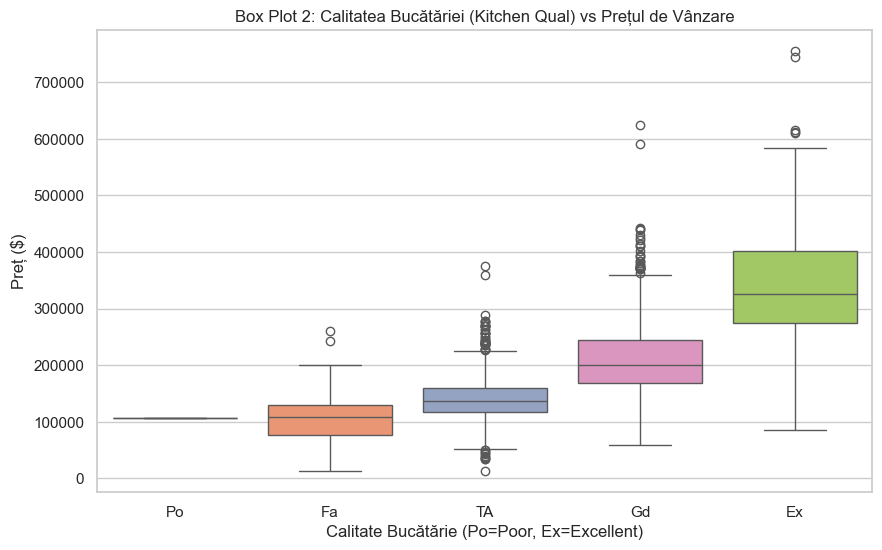

C:\Users\andre\AppData\Local\Temp\ipykernel_41516\3305430050.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Foundation', y='SalePrice', data=housing, palette='muted')


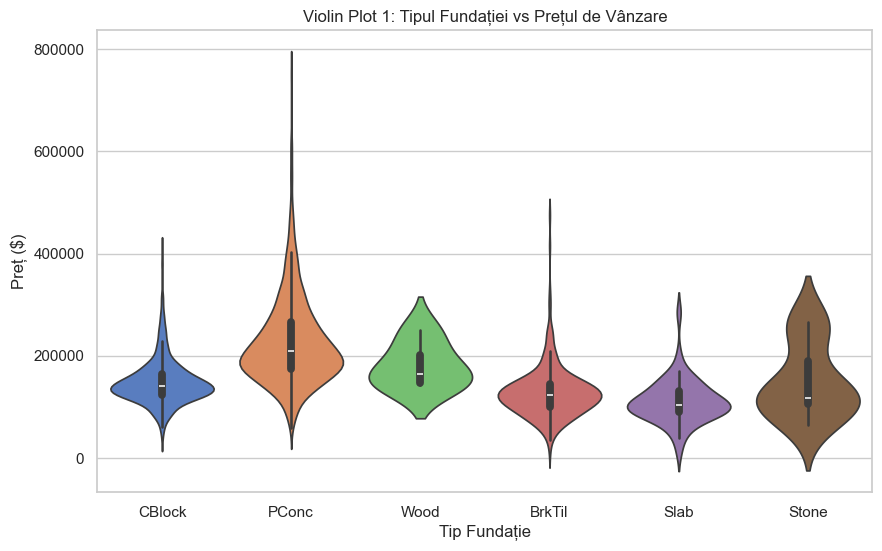

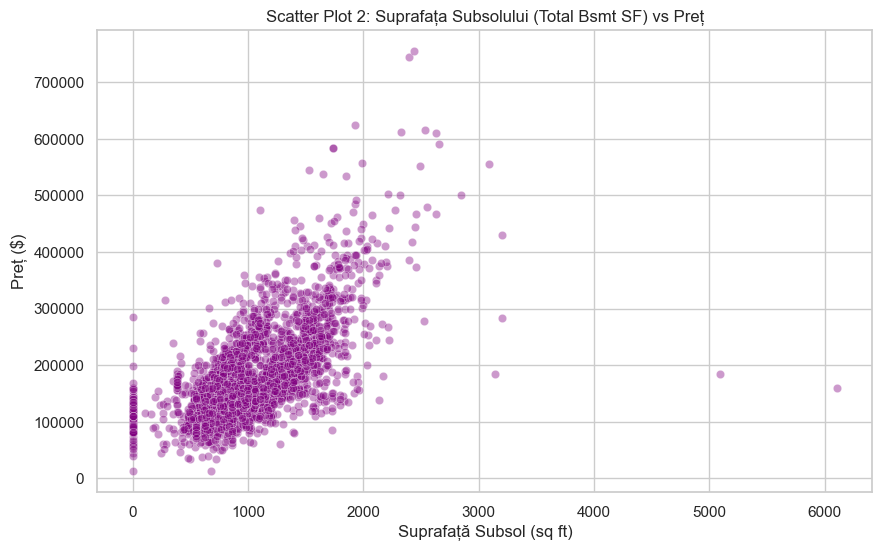

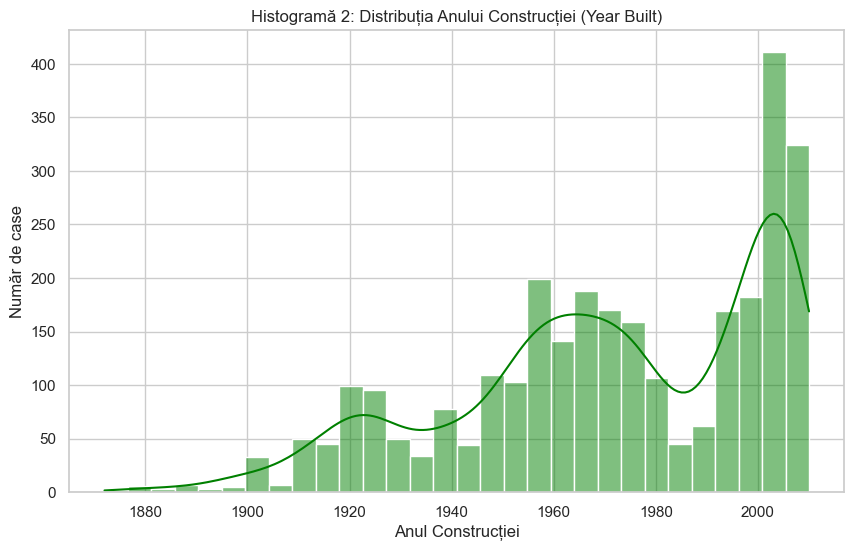

C:\Users\andre\AppData\Local\Temp\ipykernel_41516\3305430050.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Neighborhood', data=housing, order=housing['Neighborhood'].value_counts().index, palette='crest')


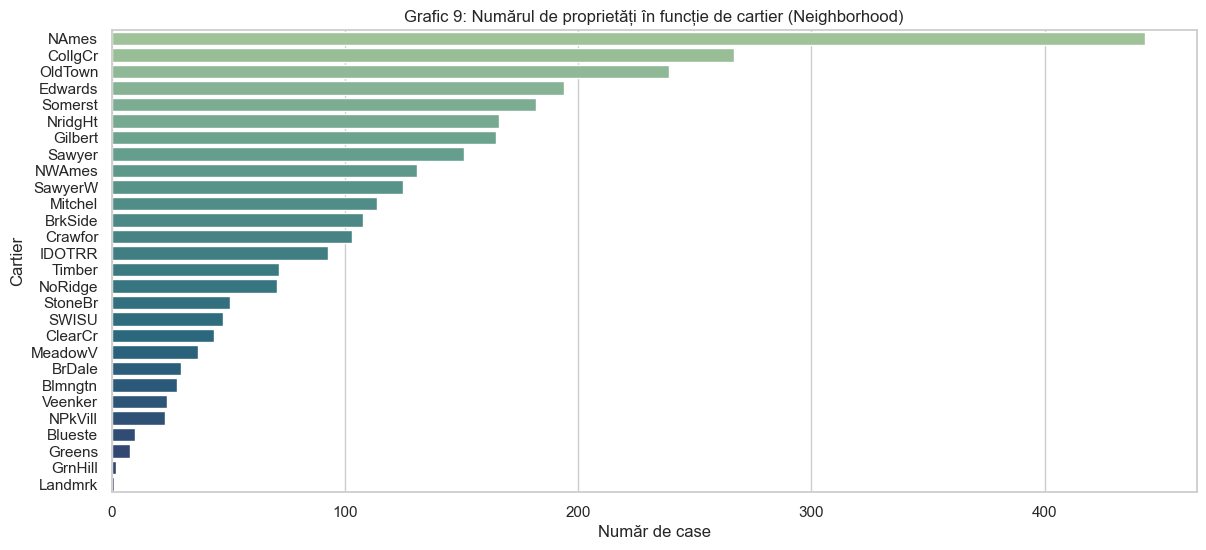

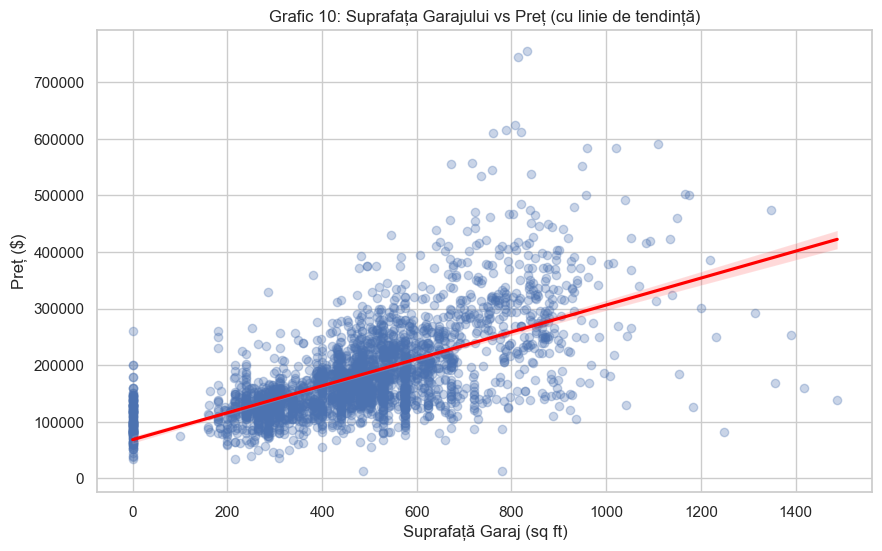

In [3]:
# Setarea unui stil vizual mai plăcut pentru grafice

sns.set_theme(style="whitegrid")



# 1. Heatmap (Corelația dintre variabilele numerice principale)

# Selectăm un subset de caracteristici numerice importante pentru a menține graficul lizibil

cols_to_plot = ['SalePrice', 'Gr Liv Area', 'Total Bsmt SF', '1st Flr SF', 'Garage Area', 'Year Built']

plt.figure(figsize=(10, 8))

corr_matrix = housing[cols_to_plot].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Heatmap 1: Corelația dintre caracteristici selectate și Preț')

plt.show()



# 2. Histogramă pentru prețul de vânzare (Distribuția țintei)

plt.figure(figsize=(10, 6))

sns.histplot(housing['SalePrice'], bins=50, kde=True, color='blue')

plt.title('Histogramă 1: Distribuția Prețului de Vânzare (SalePrice)')

plt.xlabel('Preț ($)')

plt.ylabel('Frecvență')

plt.show()



# 3. Scatter Plot (Suprafața locuibilă deasupra solului vs Preț)

# Aici putem observa vizual dacă există "Outliers" (ex: case uriașe dar ieftine)

plt.figure(figsize=(10, 6))

sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=housing, alpha=0.5, color='darkorange')

plt.title('Scatter Plot 1: Suprafața locuibilă (Gr Liv Area) vs Prețul de Vânzare')

plt.xlabel('Suprafața (sq ft)')

plt.ylabel('Preț ($)')

plt.show()



# 4. Box Plot (Calitatea generală a casei vs Preț)

plt.figure(figsize=(12, 6))

sns.boxplot(x='Overall Qual', y='SalePrice', data=housing, palette='viridis')

plt.title('Box Plot 1: Calitatea Generală (Overall Qual) vs Prețul de Vânzare')

plt.xlabel('Calitate (1-10)')

plt.ylabel('Preț ($)')

plt.show()

# 5. Box Plot pentru calitatea bucătăriei (Kitchen Qual) vs Preț

plt.figure(figsize=(10, 6))

sns.boxplot(x='Kitchen Qual', y='SalePrice', data=housing, order=['Po', 'Fa', 'TA', 'Gd', 'Ex'], palette='Set2')

plt.title('Box Plot 2: Calitatea Bucătăriei (Kitchen Qual) vs Prețul de Vânzare')

plt.xlabel('Calitate Bucătărie (Po=Poor, Ex=Excellent)')

plt.ylabel('Preț ($)')

plt.show()



# 6. Violin Plot pentru tipul fundației (Foundation) vs Preț

plt.figure(figsize=(10, 6))

sns.violinplot(x='Foundation', y='SalePrice', data=housing, palette='muted')

plt.title('Violin Plot 1: Tipul Fundației vs Prețul de Vânzare')

plt.xlabel('Tip Fundație')

plt.ylabel('Preț ($)')

plt.show()



# 7. Scatter Plot suplimentar: Suprafața subsolului vs Preț

plt.figure(figsize=(10, 6))

sns.scatterplot(x='Total Bsmt SF', y='SalePrice', data=housing, alpha=0.4, color='purple')

plt.title('Scatter Plot 2: Suprafața Subsolului (Total Bsmt SF) vs Preț')

plt.xlabel('Suprafață Subsol (sq ft)')

plt.ylabel('Preț ($)')

plt.show()



# 8. Histogramă suplimentară: Anul construcției casei (Year Built)

plt.figure(figsize=(10, 6))

sns.histplot(housing['Year Built'], bins=30, kde=True, color='green')

plt.title('Histogramă 2: Distribuția Anului Construcției (Year Built)')

plt.xlabel('Anul Construcției')

plt.ylabel('Număr de case')

plt.show()

# 9. Count Plot: Distribuția cartierelor (Neighborhood)

plt.figure(figsize=(14, 6))

sns.countplot(y='Neighborhood', data=housing, order=housing['Neighborhood'].value_counts().index, palette='crest')

plt.title('Grafic 9: Numărul de proprietăți în funcție de cartier (Neighborhood)')

plt.xlabel('Număr de case')

plt.ylabel('Cartier')

plt.show()



# 10. Scatter Plot cu regresie: Suprafața garajului vs Preț

plt.figure(figsize=(10, 6))

sns.regplot(x='Garage Area', y='SalePrice', data=housing, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Grafic 10: Suprafața Garajului vs Preț (cu linie de tendință)')

plt.xlabel('Suprafață Garaj (sq ft)')

plt.ylabel('Preț ($)')

plt.show()